In [94]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
import main as m
from scipy.stats import rankdata, norm
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter(action='ignore', category=FutureWarning) # to minimise output verbosity later
warnings.simplefilter('ignore', ConvergenceWarning) 

from IPython.display import Image, display

In [3]:
# file paths
DB_PATH = 'human_genome.db' # also needs to be changed in main.py if not this path
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'

In [4]:
SAMPLE_ID = 'random_id' # change if sample ID column has a different name
# sample_id also needs to be changed in main.py if not SAMPLE_ID

In [5]:
# depending on data structure, set booleans
oncotree_code_in_sg_data = False # if 'oncotree code' is already in germline and somatic data (gene expression data will be used to map if set to False)
diag_in_sg_data = False # analogous to oncotree code

# Initial Data Loading & Formatting

In [6]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet(GERMLINE_DATA_PATH)
somatic_raw = pd.read_parquet(SOMATIC_DATA_PATH)
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

In [7]:
splicing = pd.read_parquet(SPLICING_DATA_PATH)
outrider = pd.read_parquet(EXPRESSION_DATA_PATH)
protein = pd.read_parquet(PROTEIN_DATA_PATH)

In [8]:
# format ensembl gene ID column to match database
res['geneID_filtered'] = res['Gene'].str.split('.').str[0].str.strip()
outrider['geneID_filtered'] = outrider['geneID_short'].str.split('.').str[0].str.strip()
protein['geneID_filtered'] = protein['geneID_short'].str.split('.').str[0].str.strip()
splicing['geneID_filtered'] = splicing['geneID_short'].str.split('.').str[0].str.strip()

In [9]:
if not oncotree_code_in_sg_data: # use gene exp. data to map oncotree code for samples
    sample_to_oncotree = outrider[[SAMPLE_ID, 'Oncotree Code']].drop_duplicates().set_index(SAMPLE_ID)['Oncotree Code'].to_dict()
    res['Oncotree Code'] = res[SAMPLE_ID].map(sample_to_oncotree)
if not diag_in_sg_data:
    sample_to_diag = outrider[[SAMPLE_ID, 'Diag']].drop_duplicates().set_index(SAMPLE_ID)['Diag'].to_dict()
    res['Diag'] = res[SAMPLE_ID].map(sample_to_diag)

In [10]:
# get generic gene names instead of symbols
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

In [11]:
def map_and_clean_ids(df, id_column):
    df['geneID_filtered'] = df[id_column].astype(str).str.split('.').str[0].str.strip() # just for double security
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    return df

res = map_and_clean_ids(res, 'Gene')
outrider = map_and_clean_ids(outrider, 'geneID_short')
protein = map_and_clean_ids(protein, 'geneID_short')
splicing = map_and_clean_ids(splicing, 'geneID_short')

In [12]:
# map chromosome number to each gene
res['chrom'] = res['seqnames'] # if a column already has the corresponding chromosomes

conn = sqlite3.connect(DB_PATH)
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

# for the dataframes that do not have the chromosomes already mapped
outrider['chrom'] = outrider['geneID_filtered'].map(gene_chrom_map)
protein['chrom'] = protein['geneID_filtered'].map(gene_chrom_map)
splicing['chrom'] = splicing['geneID_filtered'].map(gene_chrom_map)

In [13]:
interested = False
interested_df = outrider
# if it is interesting, check the percentage of genes that are missing chromosome mappings
if interested:
    nan_genes_count = interested_df[interested_df['chrom'].isna()]['geneID_filtered'].nunique()
    total_unique_genes = interested_df['geneID_filtered'].nunique()

    print(f"unique genes: {total_unique_genes}")
    print(f"unique genes with NaN chromosome: {nan_genes_count}")
    print(f"Percentage missing: {(nan_genes_count / total_unique_genes) * 100:.2f}%")


# Initial Plots

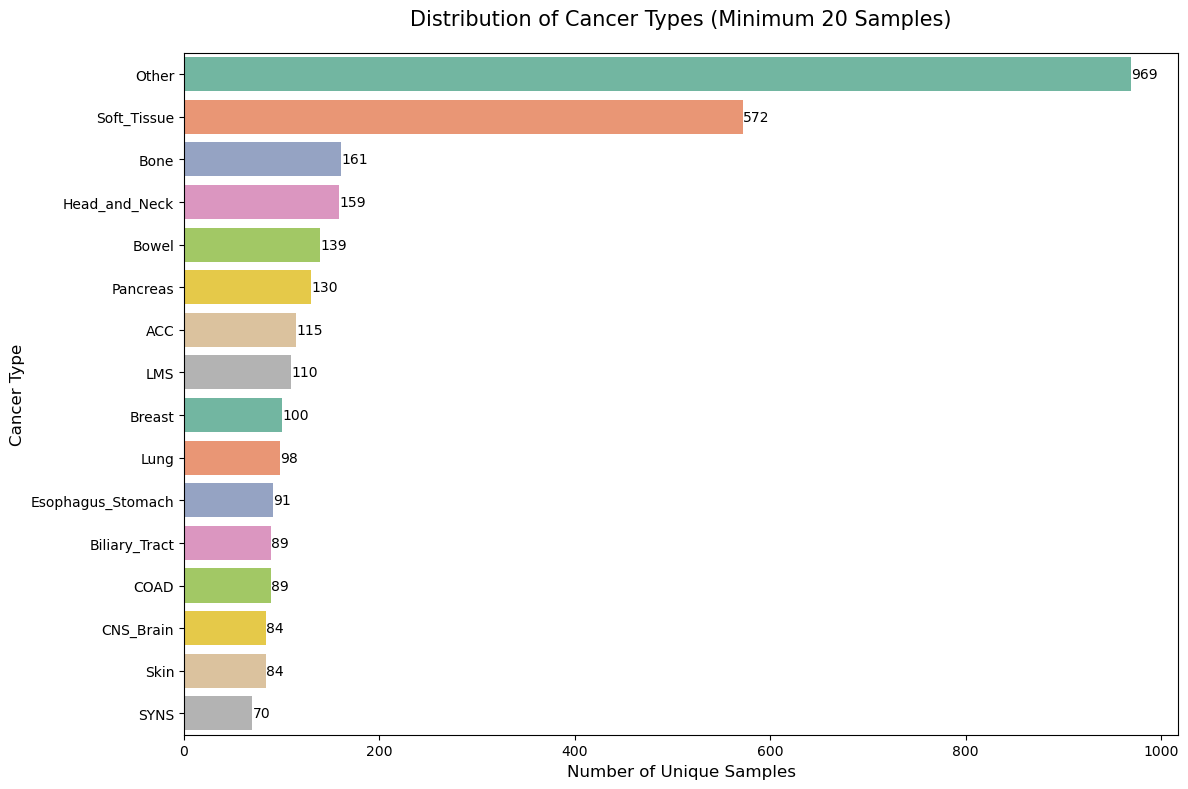

In [14]:
# plot the distribution of cancer types with minimum n affected samples, can use oncotree code or diag
def plot_cancer_type_distribution(res_df, min_samples=5, col='Diag'):
    cancer_counts = res_df.groupby(col)[SAMPLE_ID].nunique().reset_index()
    cancer_counts.columns = [col, 'Sample_Count']

    filtered_counts = cancer_counts[cancer_counts['Sample_Count'] >= min_samples].sort_values(
        by='Sample_Count', ascending=False
    )

    if filtered_counts.empty:
        print(f"No cancer types found with at least {min_samples} samples.")
        return

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=filtered_counts,
        y=col,
        x='Sample_Count',
        palette='Set2'
    )

    plt.title(f"Distribution of Cancer Types (Minimum {min_samples} Samples)", fontsize=15, pad=20)
    plt.xlabel("Number of Unique Samples", fontsize=12)
    plt.ylabel("Cancer Type", fontsize=12)

    for i, count in enumerate(filtered_counts['Sample_Count']):
        plt.text(count + 0.5, i, str(count), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_cancer_type_distribution(res, min_samples=20)

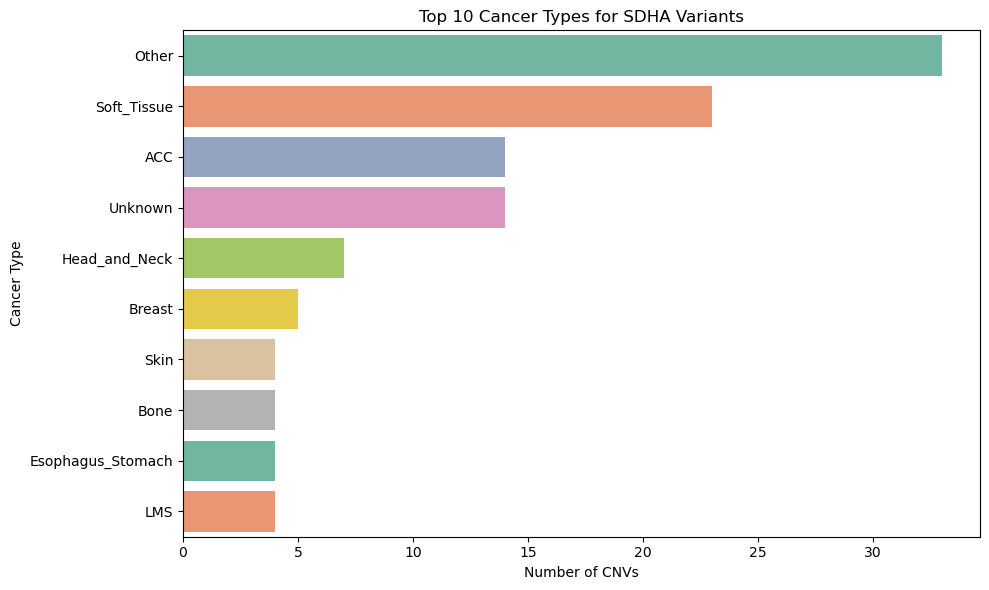

In [15]:
# plot the distribution of a given gene across top n most frequent cancer types
def gene_distribution_new(gene_symbol, res_df, top_n=10, col='Diag', print_output=False):
    gene_data = res_df[res_df['Gene'] == gene_symbol].copy()

    if gene_data.empty:
        return f"No variants found for {gene_symbol}."

    total_cnvs = len(gene_data)
    unique_samples = gene_data[SAMPLE_ID].nunique()

    gene_data[col] = gene_data[col].fillna('Unknown')
    distribution = gene_data[col].value_counts()
    top_distribution = distribution.head(top_n)

    if print_output:
        print(f"--- Analysis for {gene_symbol} ---")
        print(f"Total CNV entries: {total_cnvs}")
        print(f"Unique samples affected: {unique_samples}\n")
        print(f"Top {top_n} cancer types:")
        print(top_distribution)

    plot_data = gene_data[gene_data[col].isin(top_distribution.index)]

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=plot_data,
        y=col,
        palette='Set2',
        order=top_distribution.index
    )
    plt.title(f"Top {top_n} Cancer Types for {gene_symbol} Variants")
    plt.xlabel("Number of CNVs")
    plt.ylabel("Cancer Type")
    plt.tight_layout()
    plt.show()

gene_distribution_new('SDHA', res)

# Initial Statistical Tests

Wilcoxon Rank Sum + FDR Correction

In [16]:
# matrix of counts per sample per chromosome => needed for chromosome-aware stats test
def get_chrom_counts(outlier_df, sample_id=SAMPLE_ID):
    return outlier_df.groupby([sample_id, 'chrom']).size().unstack(fill_value=0)

all_ids = res[SAMPLE_ID].unique()

chrom_counts_gene = get_chrom_counts(outrider).reindex(all_ids, fill_value=0)
chrom_counts_prot = get_chrom_counts(protein).reindex(all_ids, fill_value=0)
chrom_counts_spl = get_chrom_counts(splicing).reindex(all_ids, fill_value=0)

# for gene + protein overlap
gene_prot_overlap = pd.merge(
    outrider,
    protein,
    on=[SAMPLE_ID, 'geneID_filtered', 'chrom']
).drop_duplicates(subset=[SAMPLE_ID, 'geneID_filtered'])

chrom_counts_gene_prot_overlap = get_chrom_counts(gene_prot_overlap).reindex(all_ids, fill_value=0)

In [17]:
# calculate sample-gene burdens
def calculate_burdens(outrider_df, protein_df, splicing_df, res_df, sample_id=SAMPLE_ID):
    burdens = {}

    burdens['gene'] = outrider_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['protein'] = protein_df.groupby(sample_id)['geneID_filtered'].nunique()
    burdens['splicing'] = splicing_df.groupby(sample_id)['geneID_filtered'].nunique()

    all_samples = res_df[sample_id].unique()
    return {k: v.reindex(all_samples, fill_value=0).reset_index(name='burden') for k, v in burdens.items()}

In [18]:
# get the testable genes by checking if they have minimum n carriers
def get_testable_genes(outlier_df, res_df, min_carriers=5):
    outlier_genes = set(outlier_df['geneID_filtered'].unique())
    res_filtered = res_df[res_df['geneID_filtered'].isin(outlier_genes)]

    carrier_counts = (
        res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
        ['geneID_filtered']
        .value_counts()
    )

    valid_genes = carrier_counts[carrier_counts >= min_carriers].index.tolist()

    print(f"Total testable genes (conventional names): {len(valid_genes)}")
    return valid_genes

In [19]:
# wilcoxon rank sum test + FDR correction => this test is not chromosome 'aware'
def stats_test_no_chrom_awareness(genes_to_test, res_df, burden_df, filter_sig=True):
    if not genes_to_test:
        return pd.DataFrame()

    burden_df = burden_df.copy()
    burden_df['global_rank'] = rankdata(burden_df['burden'])
    N = len(burden_df)

    res_filtered = res_df[res_df['geneID_filtered'].isin(genes_to_test)]
    unique_carriers = res_filtered.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

    merged = unique_carriers.merge(
        burden_df[[SAMPLE_ID, 'global_rank']],
        on=SAMPLE_ID,
        how='inner'
    )

    stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
        n_carriers='count',
        rank_sum='sum'
    ).reset_index()
    stats_df.rename(columns={'geneID_filtered': 'Gene'}, inplace=True)

    n1 = stats_df['n_carriers']
    n2 = N - n1
    s = stats_df['rank_sum']

    expected = n1 * (N + 1) / 2.0
    std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

    z_scores = (s - expected) / std_dev
    stats_df['p_val'] = norm.sf(z_scores)

    stats_df = stats_df.drop(columns=['rank_sum'])

    if not stats_df.empty:
        _, stats_df['padj'], _, _ = multipletests(stats_df['p_val'], method='fdr_bh')

        if filter_sig:
            return stats_df[stats_df['padj'] < 0.05].sort_values('padj')
        else:
            return stats_df.sort_values('p_val')

    return stats_df

# chromosome 'aware' stats test => outliers on the same chromosome as a CNV will be removed
def stats_test(genes_to_test, res_df, chrom_counts_matrix, filter_sig=True, alpha=0.05):
    valid_res = res_df.dropna(subset=['chrom'])

    valid_genes_in_res = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes_in_res]

    results = []

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index
    N = len(all_samples)

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in genes_by_chrom.items():

        current_chrom_outliers = chrom_counts_matrix.get(chrom, 0)
        adj_burden = total_burden_series - current_chrom_outliers

        global_ranks = pd.Series(rankdata(adj_burden), index=all_samples)

        res_subset = valid_res[valid_res['geneID_filtered'].isin(genes)]
        unique_carriers = res_subset.drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])

        merged = unique_carriers.merge(global_ranks.rename('global_rank'),
                                      left_on=SAMPLE_ID, right_index=True, how='inner')

        stats_df = merged.groupby('geneID_filtered')['global_rank'].agg(
            n_carriers='count',
            rank_sum='sum'
        ).reset_index()

        n1 = stats_df['n_carriers']
        n2 = N - n1
        s = stats_df['rank_sum']
        expected = n1 * (N + 1) / 2.0
        std_dev = np.sqrt(n1 * n2 * (N + 1) / 12.0)

        z_scores = (s - expected) / std_dev
        stats_df['p_val'] = norm.sf(z_scores)

        results.append(stats_df)

    if not results:
        return pd.DataFrame()

    final_stats_df = pd.concat(results).rename(columns={'geneID_filtered': 'Gene'})

    if not final_stats_df.empty:
        _, final_stats_df['padj'], _, _ = multipletests(final_stats_df['p_val'], method='fdr_bh')
        if filter_sig:
            return final_stats_df[final_stats_df['padj'] < alpha].sort_values('padj')
        return final_stats_df.sort_values('p_val')

    return final_stats_df

In [20]:
# burdens dict, needed either for non-chromosome aware stats test or plotting later
burdens_dict = calculate_burdens(outrider, protein, splicing, res)

# gene outliers
genes_gene = get_testable_genes(outrider, res, min_carriers=20)
sig_gene = stats_test(genes_gene, res, chrom_counts_gene)

# protein outliers
genes_prot = get_testable_genes(protein, res, min_carriers=20)
sig_prot = stats_test(genes_prot, res, chrom_counts_prot, filter_sig=False, alpha=0.1)

# splicing outliers
genes_spl = get_testable_genes(splicing, res, min_carriers=20)
sig_spl = stats_test(genes_spl, res, chrom_counts_spl, filter_sig=False, alpha=0.05)

# gene + protein outliers
genes_gene_prot_overlap = get_testable_genes(gene_prot_overlap, res, min_carriers=5)
sig_gene_prot_overlap = stats_test(genes_gene_prot_overlap, res, chrom_counts_gene_prot_overlap, filter_sig=True, alpha=0.05)
print(f"Sig gene+protein overlap genes: {len(sig_gene_prot_overlap)}")
# => this will likely be 0 for the 'regular' statistical test

Total testable genes (conventional names): 7076
Total testable genes (conventional names): 1946
Total testable genes (conventional names): 8425
Total testable genes (conventional names): 623
Sig gene+protein overlap genes: 0


In [21]:
# it is possible to try the stats test with the chromosome matrix of either the protein or gene data instead of the matrix of the overlap, but this will still likely produce no significant results
sig_strict_vs_prot = stats_test(genes_gene_prot_overlap, res, chrom_counts_prot, filter_sig=False)
print(sig_strict_vs_prot.head(10))

sig_strict_vs_gene = stats_test(genes_gene_prot_overlap, res, chrom_counts_gene, filter_sig=False)
print(sig_strict_vs_gene.head(10))

       Gene  n_carriers  rank_sum     p_val      padj
8     FKBP9          67  143591.5  0.001747  0.874176
20    LAS1L          27   60867.0  0.008024  0.874176
45    UQCRH          10   25317.0  0.010262  0.874176
12    MYO1G          49  102177.5  0.018131  0.874176
13   NUDCD3          54  110797.0  0.025076  0.874176
27    PBDC1          25   54445.5  0.026031  0.874176
23    TRA2A          62  125819.0  0.026956  0.874176
37    STAG2          33   69832.5  0.029514  0.874176
9    LANCL2          75  150121.5  0.029523  0.874176
34  SH3BGRL          26   56087.0  0.030147  0.874176
     Gene  n_carriers  rank_sum         p_val          padj
5    AVIL         113  267388.5  3.552168e-10  1.692139e-07
52   TSFM         112  264601.0  5.432227e-10  1.692139e-07
11   CDK4         114  264963.5  4.515928e-09  9.378077e-07
36    OS9         101  235278.5  2.487187e-08  3.873794e-06
7    ATRX          36   93712.5  6.796510e-07  8.468451e-05
17  DCTN2          64  151487.5  1.996610e-06 

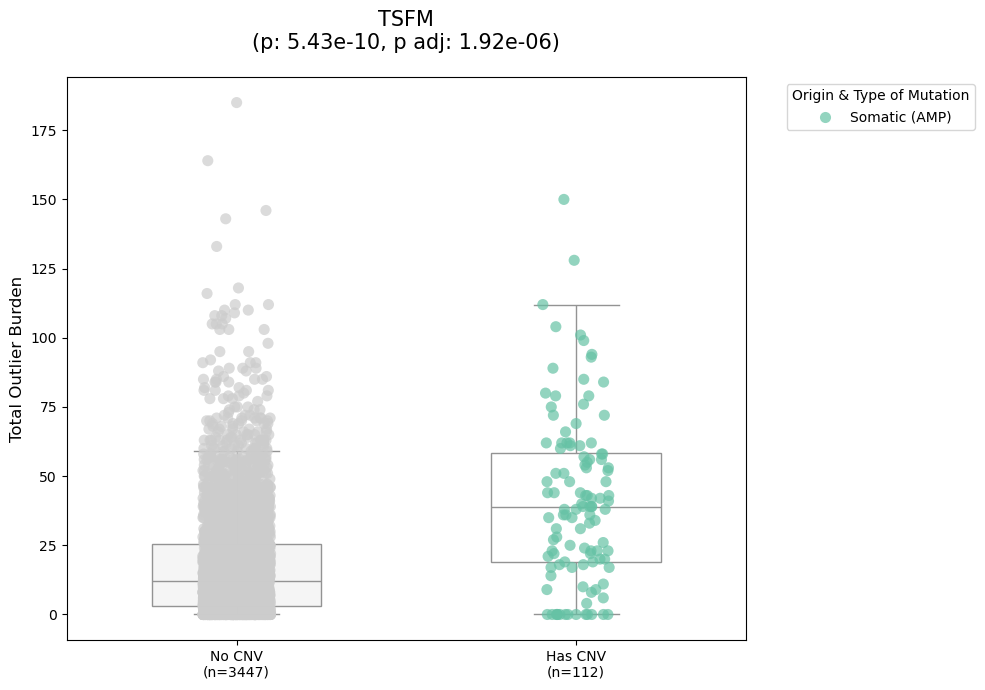

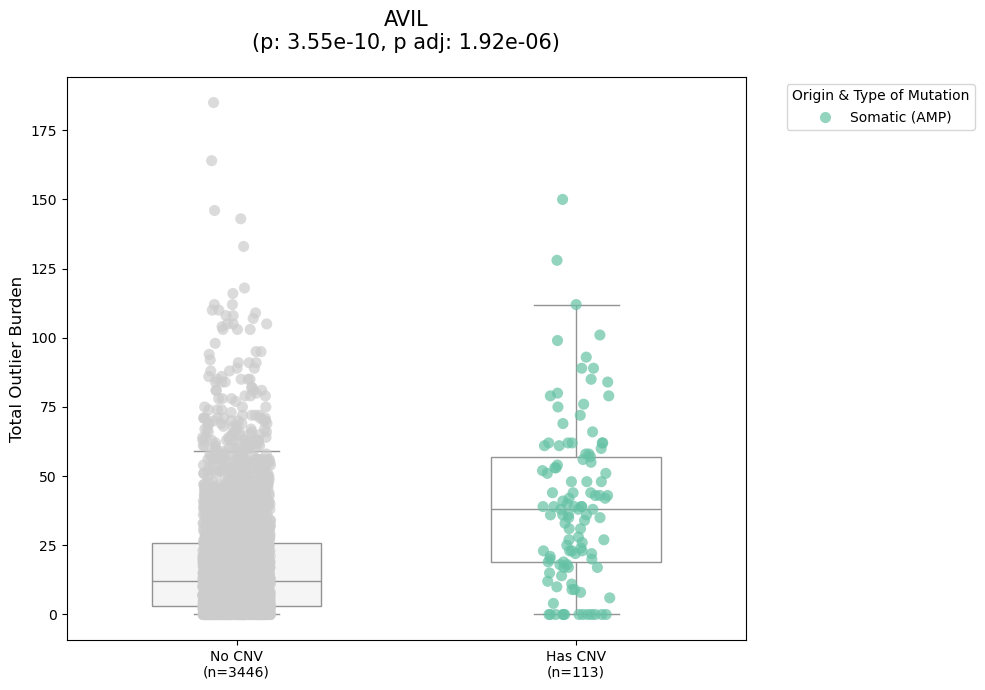

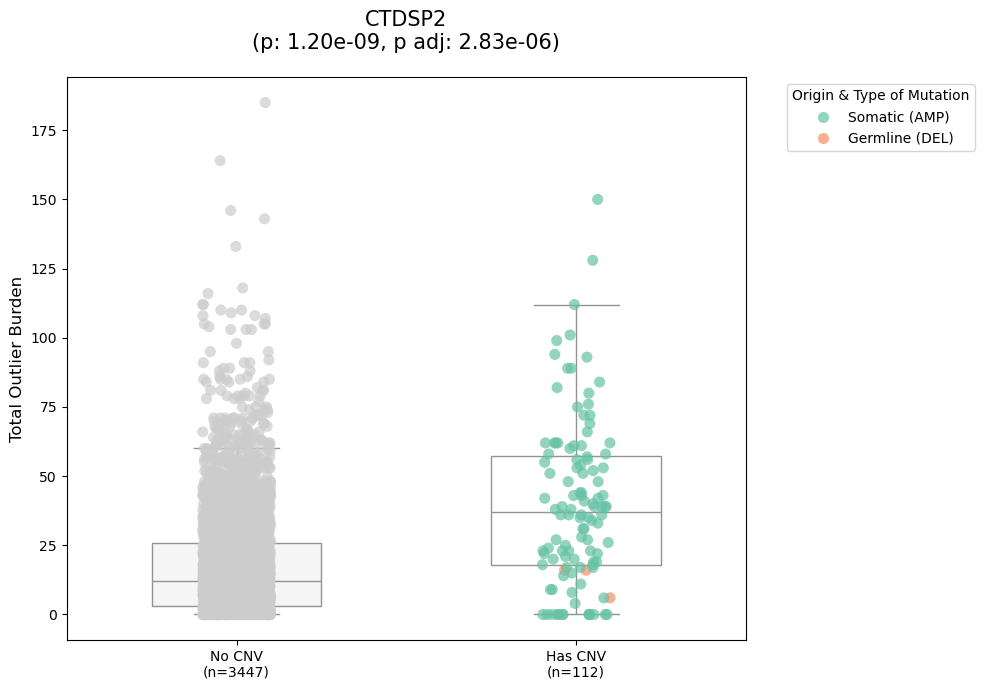

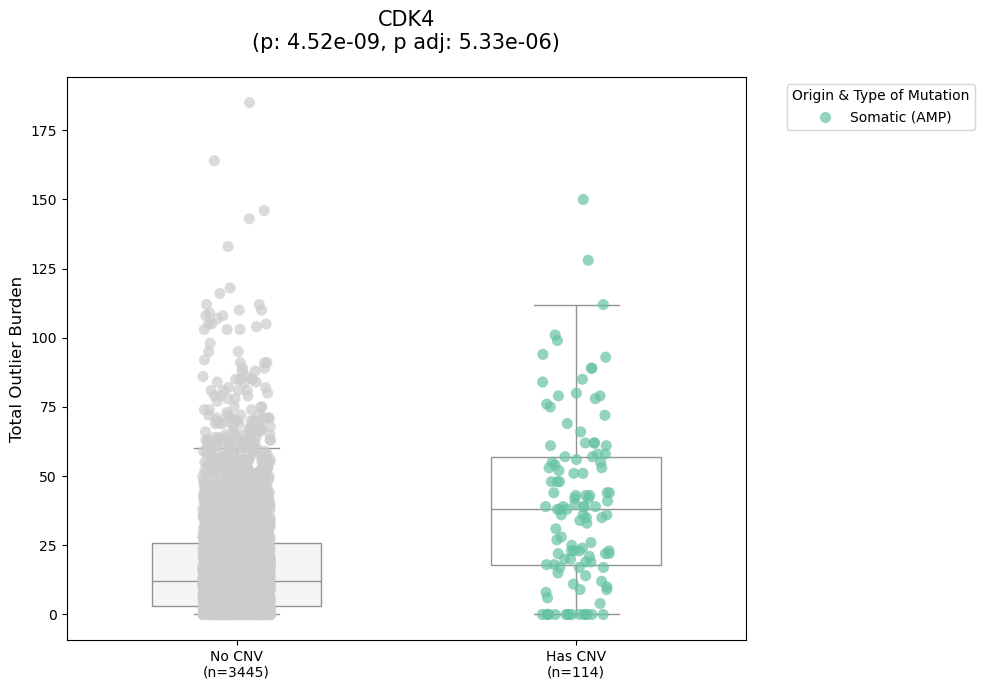

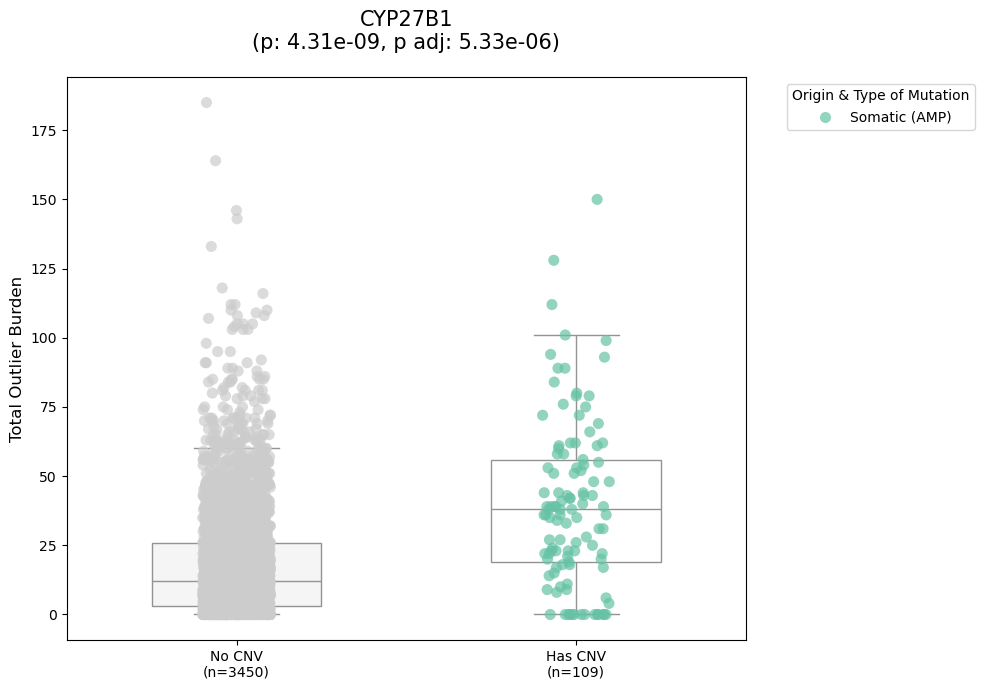

In [22]:
# plot the results of the top n most significant genes
def plot_sig_gene_results(gene_list, res_df, burden_df, stats_df):
    for gene in gene_list:
        gene_stats = stats_df[stats_df['Gene'] == gene].iloc[0]
        p_val = gene_stats['p_val']
        p_adj = gene_stats['padj']

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])

            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()

            type_label = "/".join(sorted(types))
            return f"{origin_label} ({type_label})"

        variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='Variant_Detail')

        df_plot = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        df_plot['Group'] = np.where(df_plot['Variant_Detail'].isna(), 'No CNV', 'Has CNV')
        df_plot['Variant_Detail'] = df_plot['Variant_Detail'].fillna('No Variant')

        plt.figure(figsize=(10, 7))

        sns.boxplot(data=df_plot, x='Group', y='burden',
                    palette={'No CNV': '#f5f5f5', 'Has CNV': 'white'},
                    order=['No CNV', 'Has CNV'], showfliers=False, width=0.5)

        unique_variants = [v for v in df_plot['Variant_Detail'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=df_plot, x='Group', y='burden',
                      hue='Variant_Detail',
                      palette=palette_dict,
                      order=['No CNV', 'Has CNV'],
                      jitter=True, s=8, alpha=0.7)

        plt.title(f"{gene}\n"
                  f"(p: {p_val:.2e}, p adj: {p_adj:.2e})",
                  fontsize=15, pad=20)

        plt.ylabel("Total Outlier Burden", fontsize=12)
        plt.xlabel("")

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        plt.legend([handles[i] for i in filtered_indices],
                   [labels[i] for i in filtered_indices],
                   title="Origin & Type of Mutation",
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        n_wt = len(df_plot[df_plot['Group'] == 'No CNV'])
        n_carrier = len(df_plot[df_plot['Group'] == 'Has CNV'])
        plt.xticks([0, 1], [f'No CNV\n(n={n_wt})', f'Has CNV\n(n={n_carrier})'])

        plt.tight_layout()
        plt.savefig(f'chrom_aware_gene_outliers_{gene}.png', dpi=300)
        plt.show()

top_n_genes = sig_gene.head(5)['Gene'].tolist()
plot_sig_gene_results(top_n_genes, res, burdens_dict['gene'], sig_gene)

# More advanced models accounting for zero-inflation

In [23]:
# gene exp + protein overlap
strict_overlap = pd.merge(
    outrider[[SAMPLE_ID, 'geneID_filtered']].drop_duplicates(),
    protein[[SAMPLE_ID, 'geneID_filtered']].drop_duplicates(),
    on=[SAMPLE_ID, 'geneID_filtered']
)

overlap_counts = strict_overlap.groupby(SAMPLE_ID)['geneID_filtered'].nunique()
all_samples = res[SAMPLE_ID].unique()
burden_df = overlap_counts.reindex(all_samples, fill_value=0).reset_index(name='burden')

In [24]:
# zero inflated poisson statistical test
def run_zip_tests(genes_to_test, res_df, burden_df):
    results = []
    failed_counts = {'non_convergence': 0, 'exceptions': 0}

    res_copy = res_df.copy()
    def summarize_variant(group):
        origins = set(group['origin'])
        types = set(group['Type'])
        if 'somatic' in origins and 'germline' in origins:
            origin_label = "Both"
        else:
            origin_label = list(origins)[0].capitalize()
        type_label = "/".join(sorted(types))
        return f"{origin_label}_{type_label}"

    for gene in tqdm(genes_to_test, desc="Running zero-inflated Poisson test"):
            gene_data = res_copy[res_copy['geneID_filtered'] == gene]

            if not gene_data.empty:
                variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
            else:
                variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

            model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')

            model_data['has_cnv'] = np.where(model_data['CNV_Type'].isna(), 0, 1)

            Y = model_data['burden']
            X = sm.add_constant(model_data['has_cnv'])

            n_carriers = model_data['has_cnv'].sum()

            if n_carriers < 3:
                continue

            try:
                zip_model = ZeroInflatedPoisson(endog=Y, exog=X, exog_infl=X, inflation='logit')
                zip_results = zip_model.fit(disp=False)

                if not zip_results.converged:
                    failed_counts["non_convergence"] += 1

                p_val = zip_results.pvalues['has_cnv']
                coef = zip_results.params['has_cnv']

                results.append({
                    'Gene': gene,
                    'n_carriers': n_carriers,
                    'coef': coef,
                    'p_val': p_val,
                    'converged': zip_results.converged
                })

            except Exception as e:
                failed_counts['exceptions'] += 1
                pass

    print(f"Done. Failed to converge: {failed_counts['non_convergence']}, Errors: {failed_counts['exceptions']}")

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['p_val'])
        _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
        results_df = results_df.sort_values('p_val')

    return results_df


In [25]:
# run the zip test
carrier_counts = (
    res[res['geneID_filtered'].isin(strict_overlap['geneID_filtered'])]
    .drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
    ['geneID_filtered']
    .value_counts()
)

genes_strict_overlap = carrier_counts[carrier_counts >= 5].index.tolist()

zip_stats = run_zip_tests(genes_strict_overlap, res, burden_df)

Running zero-inflated Poisson test: 100%|██████████| 623/623 [01:59<00:00,  5.20it/s]


Done. Failed to converge: 234, Errors: 0


In [26]:
print(zip_stats.head(10))

       Gene  n_carriers      coef         p_val  converged          padj
7       CPM         163  1.129809  1.151635e-20       True  7.174687e-18
30     TSFM         112  1.171681  1.279296e-17       True  3.985006e-15
605   TRIM3           7  1.744164  5.378151e-15       True  5.621851e-13
604    RRP8           7  1.744164  5.378151e-15       True  5.621851e-13
576    RHOG          10  1.744144  5.379807e-15       True  5.621851e-13
590  ARFIP2           8  1.744058  5.414303e-15       True  5.621851e-13
380   PPIL4          22  1.285444  1.778367e-14       True  1.582747e-12
448    PCM1          17  1.692969  1.237869e-13       True  9.639908e-12
202   CDK17          38  1.517050  1.570301e-13       True  1.086998e-11
28     AVIL         113  1.018011  5.431897e-13       True  3.384072e-11


In [27]:
# plot the zip results
def plot_zip_results(top_genes_list, res_df, burden_df, stats_df):
    for gene in top_genes_list:
        gene_stats = stats_df[stats_df['Gene'] == gene].iloc[0]
        p_val = gene_stats['p_val']
        p_adj = gene_stats['padj']
        coef = gene_stats['coef']
        fold_change = np.exp(coef) # e^coef gives the fold change in burden

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        plot_df = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))

        sns.boxplot(data=plot_df, x='Group', y='burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8)

        plt.title(f"{gene}\n"
                  f"(ZIP padj = {p_adj:.2e} | Exp. Increase: {fold_change:.1f}x)",
                  fontsize=15, pad=15)

        plt.ylabel("# of gene expression + protein overlap outliers", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            plt.legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        #plt.savefig(f'ZIP_Result_{gene}.png', dpi=300, bbox_inches='tight')
        plt.show()


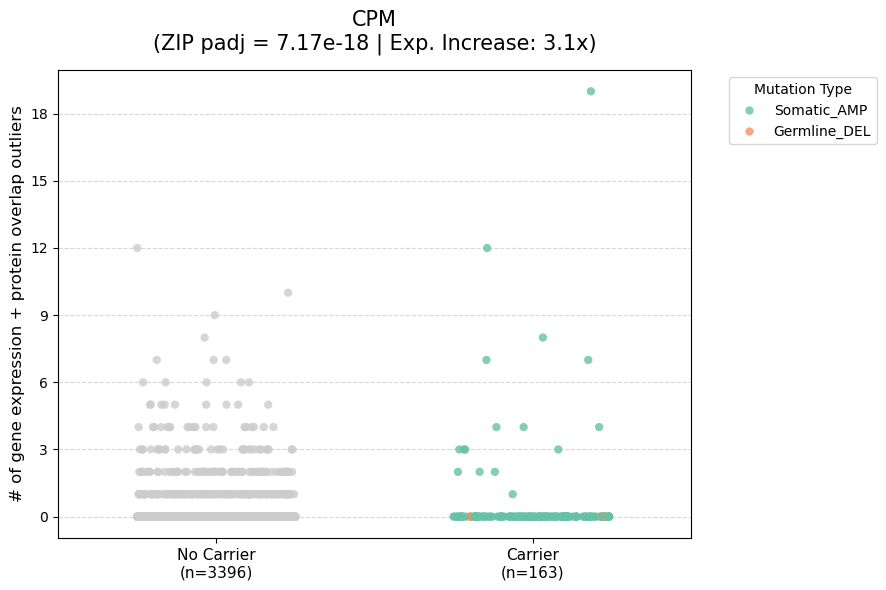

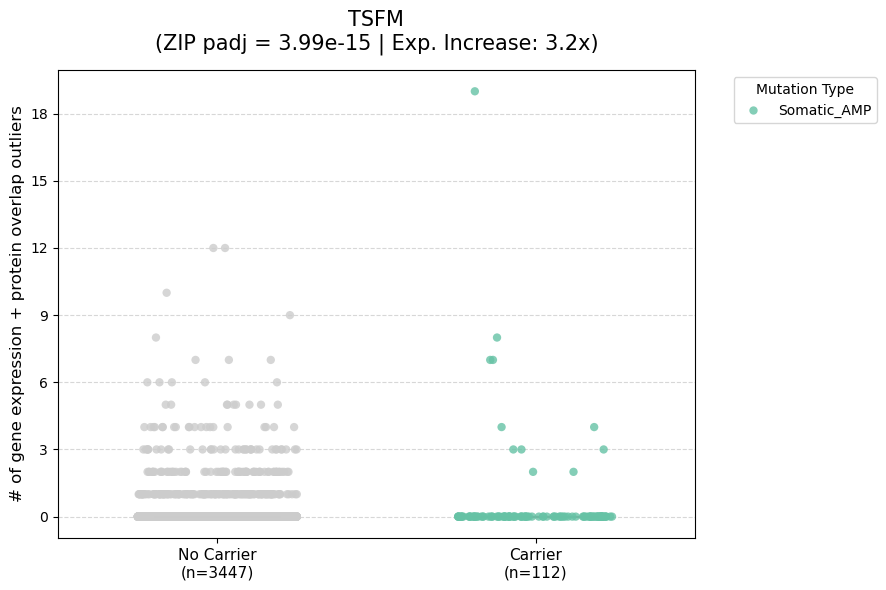

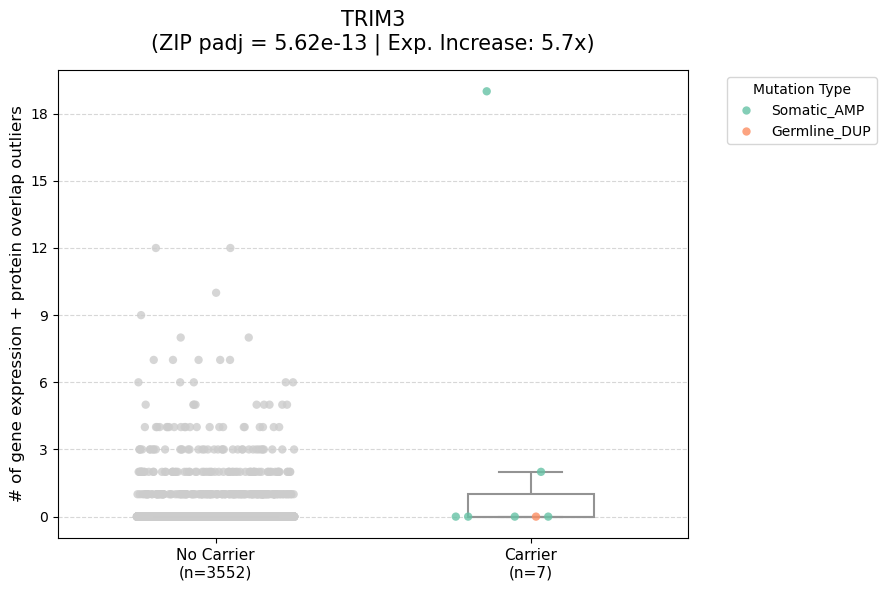

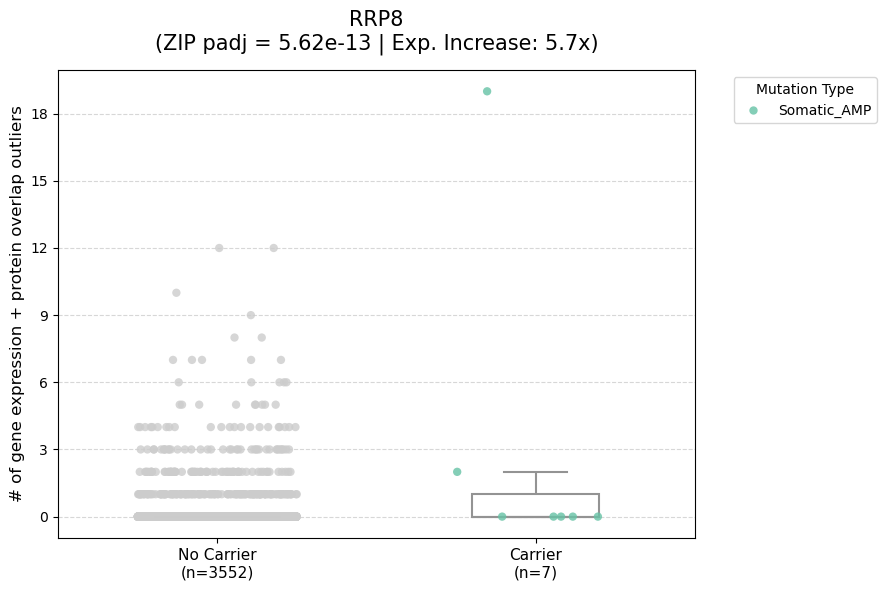

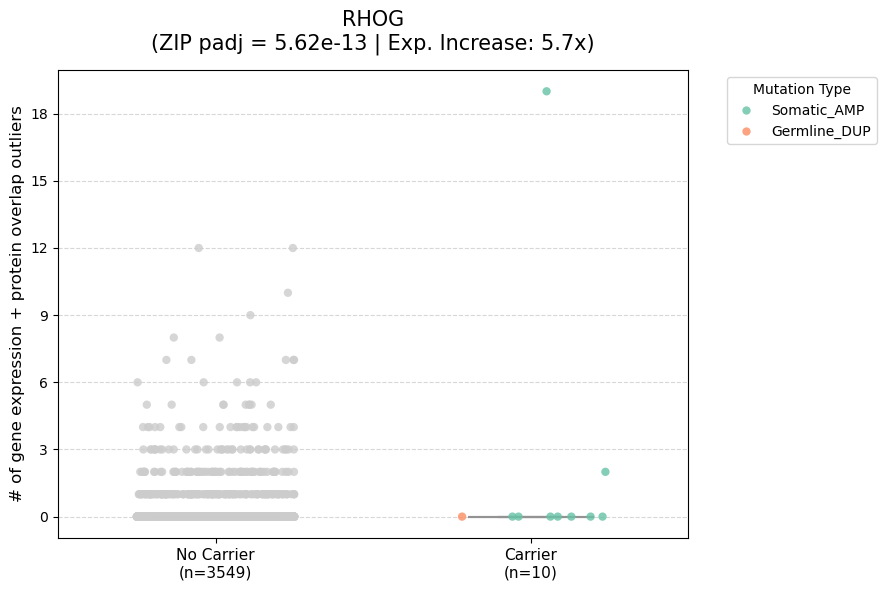

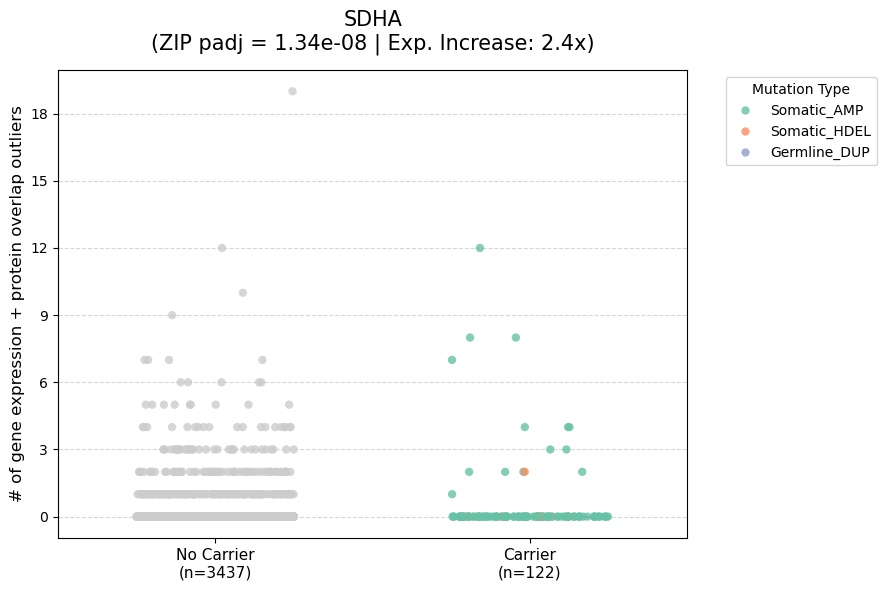

In [28]:
top_5_zip_genes = zip_stats.head(5)['Gene'].tolist()
plot_zip_results(top_5_zip_genes, res, burden_df, zip_stats)

# can also plot individual genes of interest, eg:
plot_zip_results(['SDHA'], res, burden_df, zip_stats)

Additional models

In [ ]:
from statsmodels.stats.multitest import multipletests

def run_hurdle_model(genes_to_test, res_df, burden_df):
    # 1. Logit: does CNV predict presence of burden (binary)?
    # 2. Truncated Poisson: does CNV predict burden magnitude >0?

    results = []

    for gene in tqdm(genes_to_test, desc="Running Hurdle tests"):
        gene_data = res_df[res_df['geneID_filtered'] == gene]
        variant_summary = gene_data.groupby(SAMPLE_ID).size().reset_index(name='CNV_Count')
        model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left').fillna(0)
        model_data['has_cnv'] = (model_data['CNV_Count'] > 0).astype(int)
        
        if model_data['has_cnv'].sum() < 3 or (model_data['burden'] > 0).sum() < 3:
            continue

        Y = model_data['burden']
        X = sm.add_constant(model_data['has_cnv'])

        try:
            y_binary = (Y > 0).astype(int)
            logit_model = sm.Logit(y_binary, X).fit(disp=False)
            
            pos_data = model_data[model_data['burden'] > 0].copy()
            Y_pos = pos_data['burden']
            X_pos = sm.add_constant(pos_data['has_cnv'])
            
            trunc_model = sm.Poisson(Y_pos, X_pos).fit(disp=False)

            results.append({
                'Gene': gene,
                'logit_p': logit_model.pvalues['has_cnv'],
                'trunc_p': trunc_model.pvalues['has_cnv']
            })
        except:
            continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        _, results_df['padj'], _, _ = multipletests(results_df['logit_p'], method='fdr_bh')
        results_df = results_df.sort_values('logit_p')

    return results_df

In [30]:
carrier_counts = (
    res[res['geneID_filtered'].isin(strict_overlap['geneID_filtered'])]
    .drop_duplicates(subset=['geneID_filtered', SAMPLE_ID])
    ['geneID_filtered']
    .value_counts()
)

genes_strict_overlap = carrier_counts[carrier_counts >= 5].index.tolist()

hurdle_stats = run_hurdle_model(genes_strict_overlap, res, burden_df)

Running Hurdle tests:  73%|███████▎  | 456/623 [01:00<00:22,  7.41it/s]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Hurdle tests:  74%|███████▎  | 458/623 [01:01<00:22,  7.35it/s]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Hurdle tests:  91%|█████

In [ ]:
hurdle_stats.head(10)
# 54 genes failed to converge 

,Gene,logit_p,trunc_p,padj
541,UQCRH,0.000015,0.876323,0.008559
108,PTRH2,0.000064,0.426830,0.018213
92,FKBP9,0.000421,0.667559,0.049887
519,RBM15,0.000467,0.808586,0.049887
118,NUDCD3,0.000514,0.123259,0.049887
103,CLTC,0.000526,0.555942,0.049887
139,MYO1G,0.000789,0.175318,0.057682
216,ATRX,0.000811,0.077365,0.057682
409,PKM,0.001086,0.904537,0.065147
318,PBDC1,0.001208,0.107729,0.065147


In [ ]:
# logistic test (logistic regression => find whether a variant increases likelihood for an outlier, but not by how much)
def run_logistic_tests(genes_to_test, res_df, burden_df):
    results = []
    res_copy = res_df.copy()

    def summarize_variant(group):
        origins = set(group['origin'])
        types = set(group['Type'])
        if 'somatic' in origins and 'germline' in origins:
            origin_label = "Both"
        else:
            origin_label = list(origins)[0].capitalize()
        type_label = "/".join(sorted(types))
        return f"{origin_label}_{type_label}"

    for gene in tqdm(genes_to_test, desc="Running Logistic tests"):
        gene_data = res_copy[res_copy['geneID_filtered'] == gene]

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        model_data = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        model_data['has_cnv'] = np.where(model_data['CNV_Type'].isna(), 0, 1)
        
        model_data['is_outlier'] = (model_data['burden'] > 0).astype(int)

        n_carriers = model_data['has_cnv'].sum()
        n_outliers = model_data['is_outlier'].sum()

        if n_carriers < 3 or n_outliers < 3:
            continue

        Y = model_data['is_outlier']
        X = sm.add_constant(model_data['has_cnv'])

        try:
            logit_model = sm.Logit(endog=Y, exog=X)
            logit_results = logit_model.fit(disp=False)

            p_val = logit_results.pvalues['has_cnv']
            coef = logit_results.params['has_cnv']

            results.append({
                'Gene': gene,
                'n_carriers': n_carriers,
                'coef': coef,
                'p_val': p_val,
                'converged': logit_results.mle_retvals['converged']
            })

        except Exception as e:
            pass

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df[results_df['converged'] == True].copy()
        results_df = results_df.dropna(subset=['p_val'])
        
        if not results_df.empty:
            _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
            results_df = results_df.sort_values('p_val')

    return results_df

In [34]:
log_stats = run_logistic_tests(genes_strict_overlap, res, burden_df)

Running Logistic tests:  73%|███████▎  | 456/623 [01:01<00:22,  7.55it/s]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Logistic tests:  74%|███████▎  | 458/623 [01:01<00:23,  7.04it/s]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Logistic tests:  91%

In [ ]:
log_stats.head(10)
# 49 genes failed to converge

,Gene,n_carriers,coef,p_val,converged,padj
574,UQCRH,10,2.806130,0.000015,True,0.008634
108,PTRH2,59,1.247873,0.000064,True,0.018373
92,FKBP9,67,1.081751,0.000421,True,0.050325
543,RBM15,12,2.059886,0.000467,True,0.050325
118,NUDCD3,54,1.156704,0.000514,True,0.050325
103,CLTC,61,1.104814,0.000526,True,0.050325
139,MYO1G,49,1.167565,0.000789,True,0.058189
216,ATRX,36,1.305181,0.000811,True,0.058189
418,PKM,19,1.624705,0.001086,True,0.065719
322,PBDC1,25,1.455287,0.001208,True,0.065719


A failed approach: zero-inflated negative binomial. Lots of "Hessian Inversion Warnings", likely due to mostly zeroes. 

Plotting the Hurdle test & Logistic Regression results

In [42]:
# same manner of plotting as before
def plot_model_comparison(top_genes_list, res_df, burden_df, logit_stats, hurdle_stats):
    for gene in top_genes_list:
        logit_row = logit_stats[logit_stats['Gene'] == gene]
        hurdle_row = hurdle_stats[hurdle_stats['Gene'] == gene]
        
        if logit_row.empty or hurdle_row.empty:
            print(f"Stats missing for {gene}, skipping plot.")
            continue
            
        logit_padj = logit_row.iloc[0]['padj']
        logit_coef = logit_row.iloc[0]['coef']
        odds_ratio = np.exp(logit_coef) 
        
        trunc_p = hurdle_row.iloc[0]['trunc_p']

        gene_data = res_df[res_df['geneID_filtered'] == gene].copy()

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        if not gene_data.empty:
            variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')
        else:
            variant_summary = pd.DataFrame(columns=[SAMPLE_ID, 'CNV_Type'])

        plot_df = pd.merge(burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))


        plt.axhspan(-0.5, 0.5, color='gray', alpha=0.1, zorder=0)

        sns.boxplot(data=plot_df, x='Group', y='burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5, zorder=1)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8, zorder=2)

        title_text = (
            f"{gene}\n"
            f"Logit padj: {logit_padj:.2e} (Odds Ratio: {odds_ratio:.1f}x)\n"
            f"Hurdle Truncated p-val: {trunc_p:.3f}"
        )
        plt.title(title_text, fontsize=14, pad=15)

        plt.ylabel("# of gene expression + protein overlap outliers", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if plt.gca().get_legend():
                plt.gca().get_legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

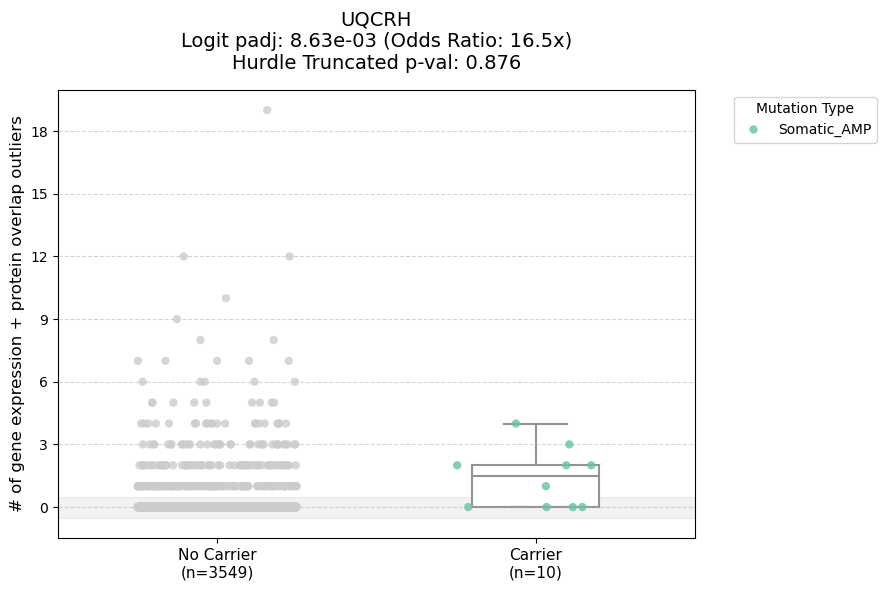

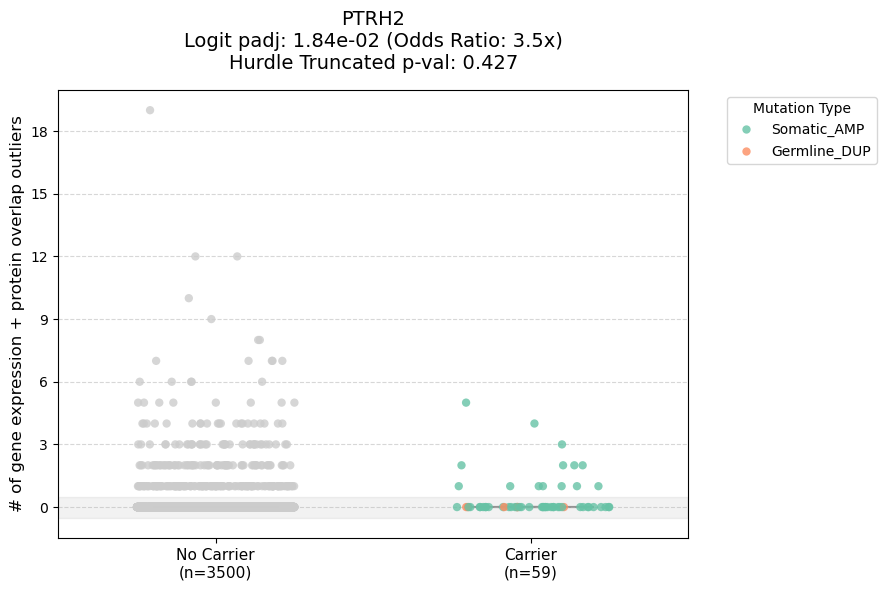

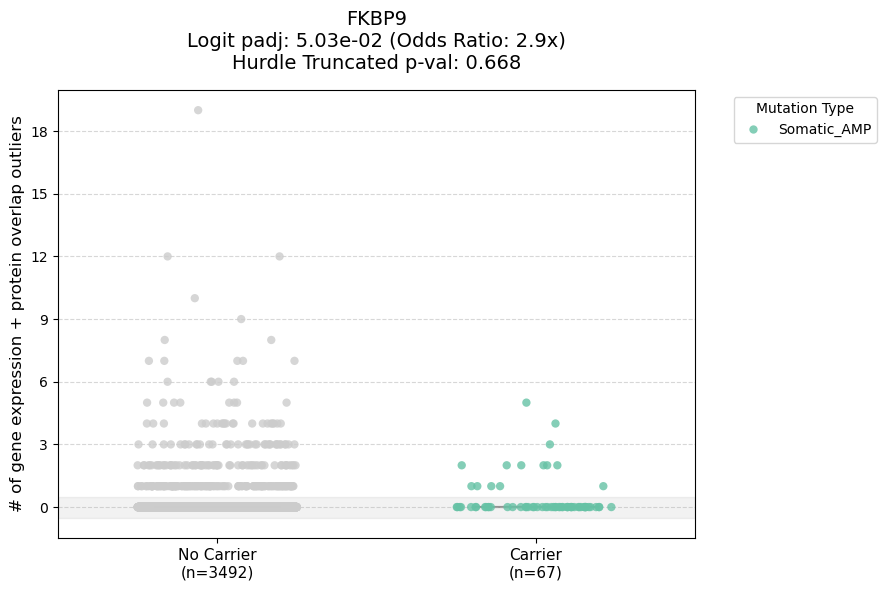

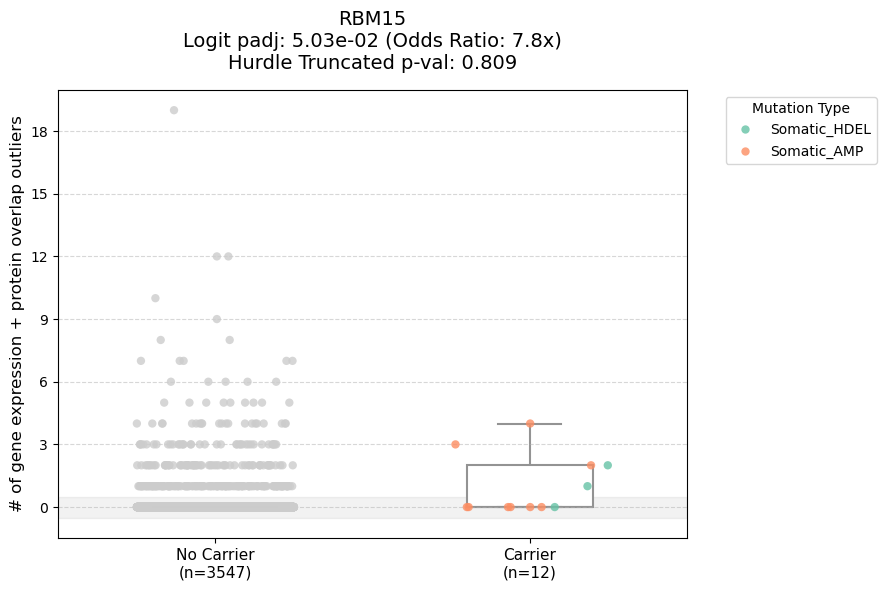

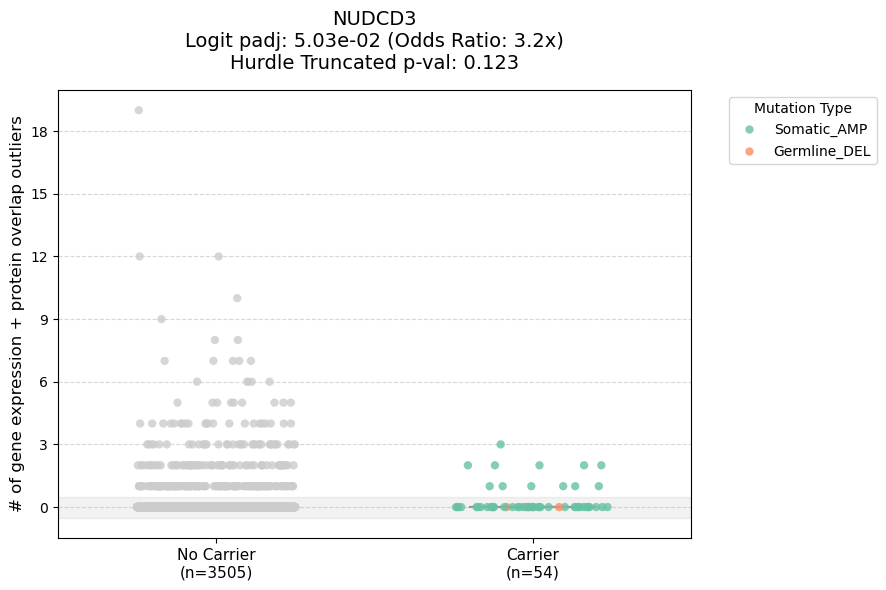

In [ ]:
top_5_genes = log_stats.head(5)['Gene'].tolist()
plot_model_comparison(top_5_genes, res, burden_df, log_stats, hurdle_stats)

'''
Explanation of graph:
- X-Axis: carrier => patient who has a muation on a given gene 
- Y-Axis: number of outliers in the gene expression + protein overlap (= burden)
- Logit padj: adjusted p-value of the logistical regression => whether a CNV on that gene causes an outlier, and by how much (Odds Ratio)
- Hurdle truncated p-val: only for carriers with y>0, does a CNV increase the burden? 
'''

In [83]:
# compare the two models 
def plot_log_hurdle_comp(logit_df, hurdle_df, top_n):
    top_n_genes = logit_df.sort_values('padj').head(top_n)[['Gene', 'padj']].copy()
    
    merged_df = pd.merge(top_n_genes, hurdle_df[['Gene', 'trunc_p']], on='Gene', how='left')
    
    merged_df['Logistic padj'] = -np.log10(merged_df['padj'] + 1e-300)
    merged_df['Truncated p-val'] = -np.log10(merged_df['trunc_p'] + 1e-300)
    
    melted_df = pd.melt(merged_df, id_vars=['Gene'], 
                        value_vars=['Logistic padj', 'Truncated p-val'],
                        var_name='Statistical Test', value_name='-log10(p-value)')
    
    plt.figure(figsize=(10, 6))
    
    
    ax = sns.barplot(data=melted_df, x='Gene', y='-log10(p-value)', 
                     hue='Statistical Test', palette='Set2')
    
    threshold = -np.log10(0.05)
    plt.axhline(threshold, color='black', linestyle='--', alpha=0.7, zorder=0)
    plt.text(top_n, threshold, 'p = 0.05', color='black', fontsize=10)
    
    plt.title(f'Top {top_n} Genes of Logistic Regression vs Hurdle Model', fontsize=15, pad=15)
    plt.ylabel('-log10(p-value)', fontsize=12)
    plt.xlabel('Gene', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

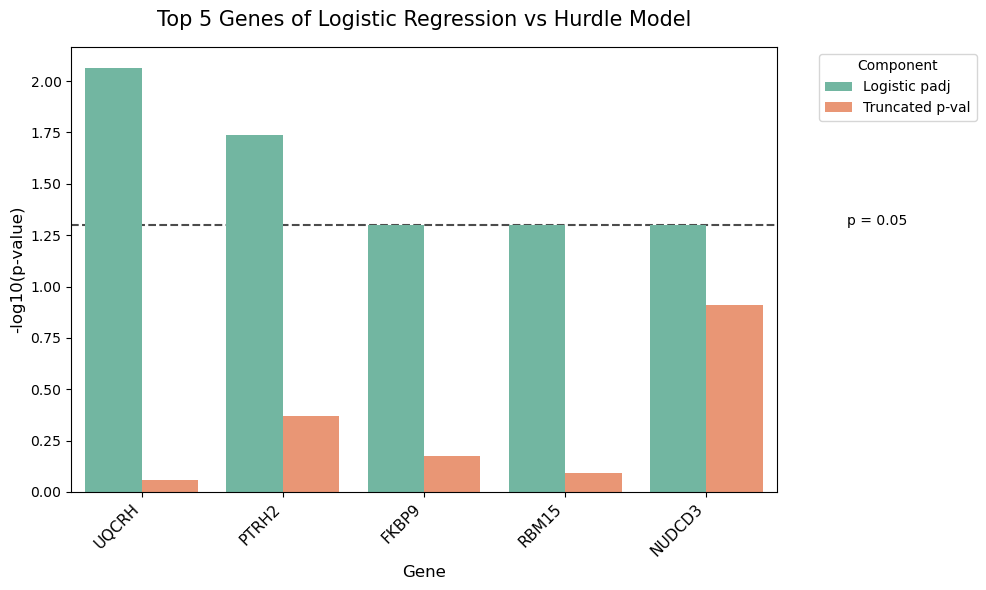

In [84]:
plot_log_hurdle_comp(log_stats, hurdle_stats, top_n=5)

# Models updated for chromosome 'awareness'

Logistical Regression Model 

In [85]:
def run_logistic_chrom_aware(genes_to_test, res_df, chrom_counts_matrix):
    valid_res = res_df.dropna(subset=['chrom'])
    valid_genes = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes]

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    results = []

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in tqdm(genes_by_chrom.items(), desc="Running Chrom-Aware Logistic"):
        
        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        
        y_binary = (adj_burden > 0).astype(int)

        for gene in genes:
            gene_data = valid_res[valid_res['geneID_filtered'] == gene]
            carrier_samples = gene_data[SAMPLE_ID].unique()

            model_data = pd.DataFrame(index=all_samples)
            model_data['has_cnv'] = model_data.index.isin(carrier_samples).astype(int)
            model_data['is_outlier'] = y_binary

            n_carriers = model_data['has_cnv'].sum()
            n_outliers = model_data['is_outlier'].sum()

            if n_carriers < 3 or n_outliers < 3:
                continue

            Y = model_data['is_outlier']
            X = sm.add_constant(model_data['has_cnv'])

            try:
                logit_model = sm.Logit(Y, X).fit(disp=False)

                if logit_model.mle_retvals['converged']:
                    results.append({
                        'Gene': gene,
                        'n_carriers': n_carriers,
                        'coef': logit_model.params['has_cnv'],
                        'p_val': logit_model.pvalues['has_cnv'],
                        'converged': True
                    })
            except Exception:
                continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['p_val'])
        _, results_df['padj'], _, _ = multipletests(results_df['p_val'], method='fdr_bh')
        results_df = results_df.sort_values('padj')

    return results_df

In [87]:
log_stats_chrom = run_logistic_chrom_aware(genes_strict_overlap, res, chrom_counts_gene_prot_overlap)

Running Chrom-Aware Logistic: 7it [00:30,  3.23s/it]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Chrom-Aware Logistic: 11it [00:46,  3.90s/it]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-

In [88]:
log_stats_chrom.head(10)

,Gene,n_carriers,coef,p_val,converged,padj
35,UQCRH,10,2.847506,0.000011,True,0.006425
474,FKBP9,67,1.124258,0.000250,True,0.060983
465,NUDCD3,54,1.198924,0.000321,True,0.060983
483,MYO1G,49,1.209644,0.000509,True,0.072585
191,PKM,19,1.639589,0.000978,True,0.111482
31,ALDH4A1,17,1.560604,0.003588,True,0.117887
32,EMC1,16,1.647922,0.002401,True,0.117887
5,SERBP1,23,1.396597,0.003541,True,0.117887
482,TRA2A,62,1.022089,0.001802,True,0.117887
463,EGFR,80,0.900845,0.002751,True,0.117887


Hurdle Model

In [89]:
def run_hurdle_chrom_aware(genes_to_test, res_df, chrom_counts_matrix):
    valid_res = res_df.dropna(subset=['chrom'])
    valid_genes = valid_res['geneID_filtered'].unique()
    genes_to_test = [g for g in genes_to_test if g in valid_genes]

    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    results = []

    genes_by_chrom = valid_res[valid_res['geneID_filtered'].isin(genes_to_test)].groupby('chrom')['geneID_filtered'].unique()

    for chrom, genes in tqdm(genes_by_chrom.items(), desc="Running Chrom-Aware Hurdle"):
        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        y_binary = (adj_burden > 0).astype(int)

        for gene in genes:
            gene_data = valid_res[valid_res['geneID_filtered'] == gene]
            carrier_samples = gene_data[SAMPLE_ID].unique()

            model_data = pd.DataFrame(index=all_samples)
            model_data['has_cnv'] = model_data.index.isin(carrier_samples).astype(int)
            model_data['adj_burden'] = adj_burden
            model_data['is_outlier'] = y_binary

            if model_data['has_cnv'].sum() < 3 or model_data['is_outlier'].sum() < 3:
                continue

            try:
                Y_logit = model_data['is_outlier']
                X_logit = sm.add_constant(model_data['has_cnv'])
                logit_model = sm.Logit(Y_logit, X_logit).fit(disp=False)
                
                if not logit_model.mle_retvals['converged']:
                    continue

                pos_data = model_data[model_data['adj_burden'] > 0]
                Y_pos = pos_data['adj_burden']
                X_pos = sm.add_constant(pos_data['has_cnv'])
                
                trunc_model = sm.Poisson(Y_pos, X_pos).fit(disp=False)

                if np.isnan(trunc_model.pvalues['has_cnv']):
                    continue

                results.append({
                    'Gene': gene,
                    'logit_p': logit_model.pvalues['has_cnv'],
                    'trunc_p': trunc_model.pvalues['has_cnv']
                })
            except Exception:
                continue

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.dropna(subset=['logit_p'])
        _, results_df['padj'], _, _ = multipletests(results_df['logit_p'], method='fdr_bh')
        results_df = results_df.sort_values('padj')

    return results_df

In [90]:
hurdle_stats_chrom = run_hurdle_chrom_aware(genes_strict_overlap, res, chrom_counts_gene_prot_overlap)

Running Chrom-Aware Hurdle: 7it [00:30,  3.24s/it]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Running Chrom-Aware Hurdle: 11it [00:46,  3.87s/it]/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-pack

In [91]:
hurdle_stats_chrom.head(10)

,Gene,logit_p,trunc_p,padj
35,UQCRH,0.000011,0.951824,0.006335
466,FKBP9,0.000250,0.452560,0.060127
457,NUDCD3,0.000321,0.089249,0.060127
475,MYO1G,0.000509,0.127697,0.071567
188,PKM,0.000978,0.240978,0.109918
5,SERBP1,0.003541,0.532025,0.116233
474,TRA2A,0.001802,0.264986,0.116233
528,ATRX,0.002991,0.155524,0.116233
455,EGFR,0.002751,0.452560,0.116233
31,ALDH4A1,0.003588,0.181591,0.116233


In [92]:
def plot_chrom_aware_model(top_genes_list, res_df, chrom_counts_matrix, logit_stats, hurdle_stats):
    total_burden_series = chrom_counts_matrix.sum(axis=1)
    all_samples = total_burden_series.index

    for gene in top_genes_list:
        logit_row = logit_stats[logit_stats['Gene'] == gene]
        hurdle_row = hurdle_stats[hurdle_stats['Gene'] == gene]
        
        if logit_row.empty or hurdle_row.empty:
            print(f"Stats missing for {gene}, skipping plot.")
            continue
            
        logit_padj = logit_row.iloc[0]['padj']
        logit_coef = logit_row.iloc[0]['coef']
        odds_ratio = np.exp(logit_coef) 
        trunc_p = hurdle_row.iloc[0]['trunc_p']

        gene_data = res_df[res_df['geneID_filtered'] == gene].dropna(subset=['chrom']).copy()
        if gene_data.empty:
            print(f"No valid chromosome data for {gene}, skipping.")
            continue
            
        chrom = gene_data['chrom'].iloc[0] 

        current_chrom_outliers = chrom_counts_matrix.get(chrom, pd.Series(0, index=all_samples))
        adj_burden = (total_burden_series - current_chrom_outliers).clip(lower=0)
        
        adj_burden_df = adj_burden.reset_index()
        adj_burden_df.columns = [SAMPLE_ID, 'adj_burden'] 

        def summarize_variant(group):
            origins = set(group['origin'])
            types = set(group['Type'])
            if 'somatic' in origins and 'germline' in origins:
                origin_label = "Both"
            else:
                origin_label = list(origins)[0].capitalize()
            type_label = "/".join(sorted(types))
            return f"{origin_label}_{type_label}"

        variant_summary = gene_data.groupby(SAMPLE_ID).apply(summarize_variant).reset_index(name='CNV_Type')

        plot_df = pd.merge(adj_burden_df, variant_summary, on=SAMPLE_ID, how='left')
        plot_df['Group'] = np.where(plot_df['CNV_Type'].isna(), 'No Carrier', 'Carrier')
        plot_df['CNV_Type'] = plot_df['CNV_Type'].fillna('No Variant')

        plt.figure(figsize=(9, 6))

        plt.axhspan(-0.5, 0.5, color='gray', alpha=0.1, zorder=0)

        sns.boxplot(data=plot_df, x='Group', y='adj_burden',
                    palette={'No Carrier': '#f5f5f5', 'Carrier': '#ffffff'},
                    order=['No Carrier', 'Carrier'],
                    showfliers=False, width=0.4, linewidth=1.5, zorder=1)

        unique_variants = [v for v in plot_df['CNV_Type'].unique() if v != 'No Variant']
        colors = sns.color_palette("Set2", len(unique_variants))
        palette_dict = dict(zip(unique_variants, colors))
        palette_dict['No Variant'] = '#cccccc'

        sns.stripplot(data=plot_df, x='Group', y='adj_burden',
                      hue='CNV_Type', palette=palette_dict,
                      order=['No Carrier', 'Carrier'],
                      jitter=0.25, s=6, alpha=0.8, zorder=2)

        title_text = (
            f"{gene} (Chromosome-Aware)\n"
            f"Logit padj: {logit_padj:.2e} (Odds Ratio: {odds_ratio:.1f}x)\n"
            f"Hurdle Truncated p-val: {trunc_p:.3f}"
        )
        plt.title(title_text, fontsize=14, pad=15)

        plt.ylabel(f"Adjusted Outlier Burden\n(Excluding Chromosome {chrom})", fontsize=12)
        plt.xlabel("")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

        handles, labels = plt.gca().get_legend_handles_labels()
        filtered_indices = [i for i, label in enumerate(labels) if label != 'No Variant']
        if filtered_indices:
            plt.legend([handles[i] for i in filtered_indices],
                       [labels[i] for i in filtered_indices],
                       title="Mutation Type",
                       bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if plt.gca().get_legend():
                plt.gca().get_legend().remove()

        n_wt = len(plot_df[plot_df['Group'] == 'No Carrier'])
        n_carrier = len(plot_df[plot_df['Group'] == 'Carrier'])
        plt.xticks([0, 1], [f'No Carrier\n(n={n_wt})', f'Carrier\n(n={n_carrier})'], fontsize=11)

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

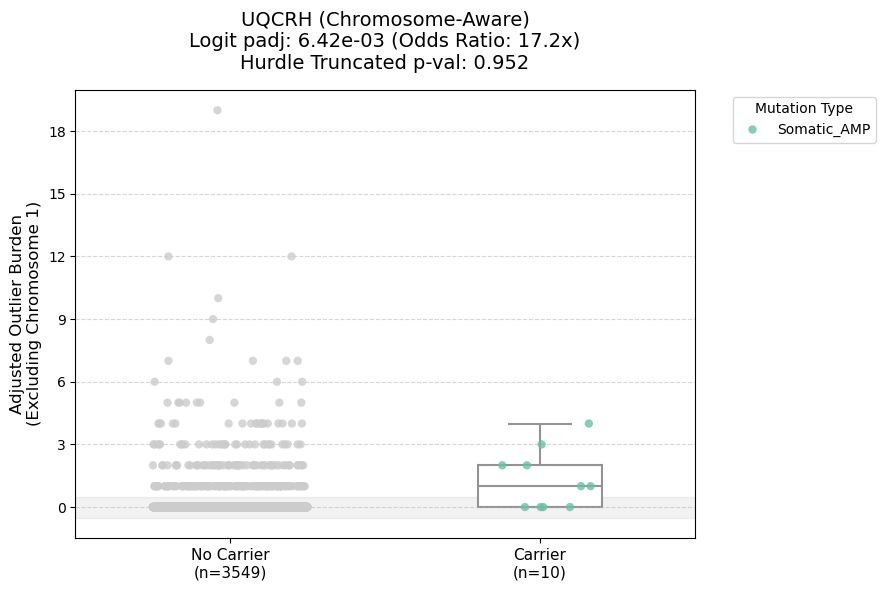

In [93]:
plot_chrom_aware_model(['UQCRH'], res, chrom_counts_gene_prot_overlap, log_stats_chrom, hurdle_stats_chrom)

Visualisation of the genes that were flagged as significant (or very close to p=0.05) before.
Image created using [PhenoGram](https://visualization.ritchielab.org/phenograms/plot)

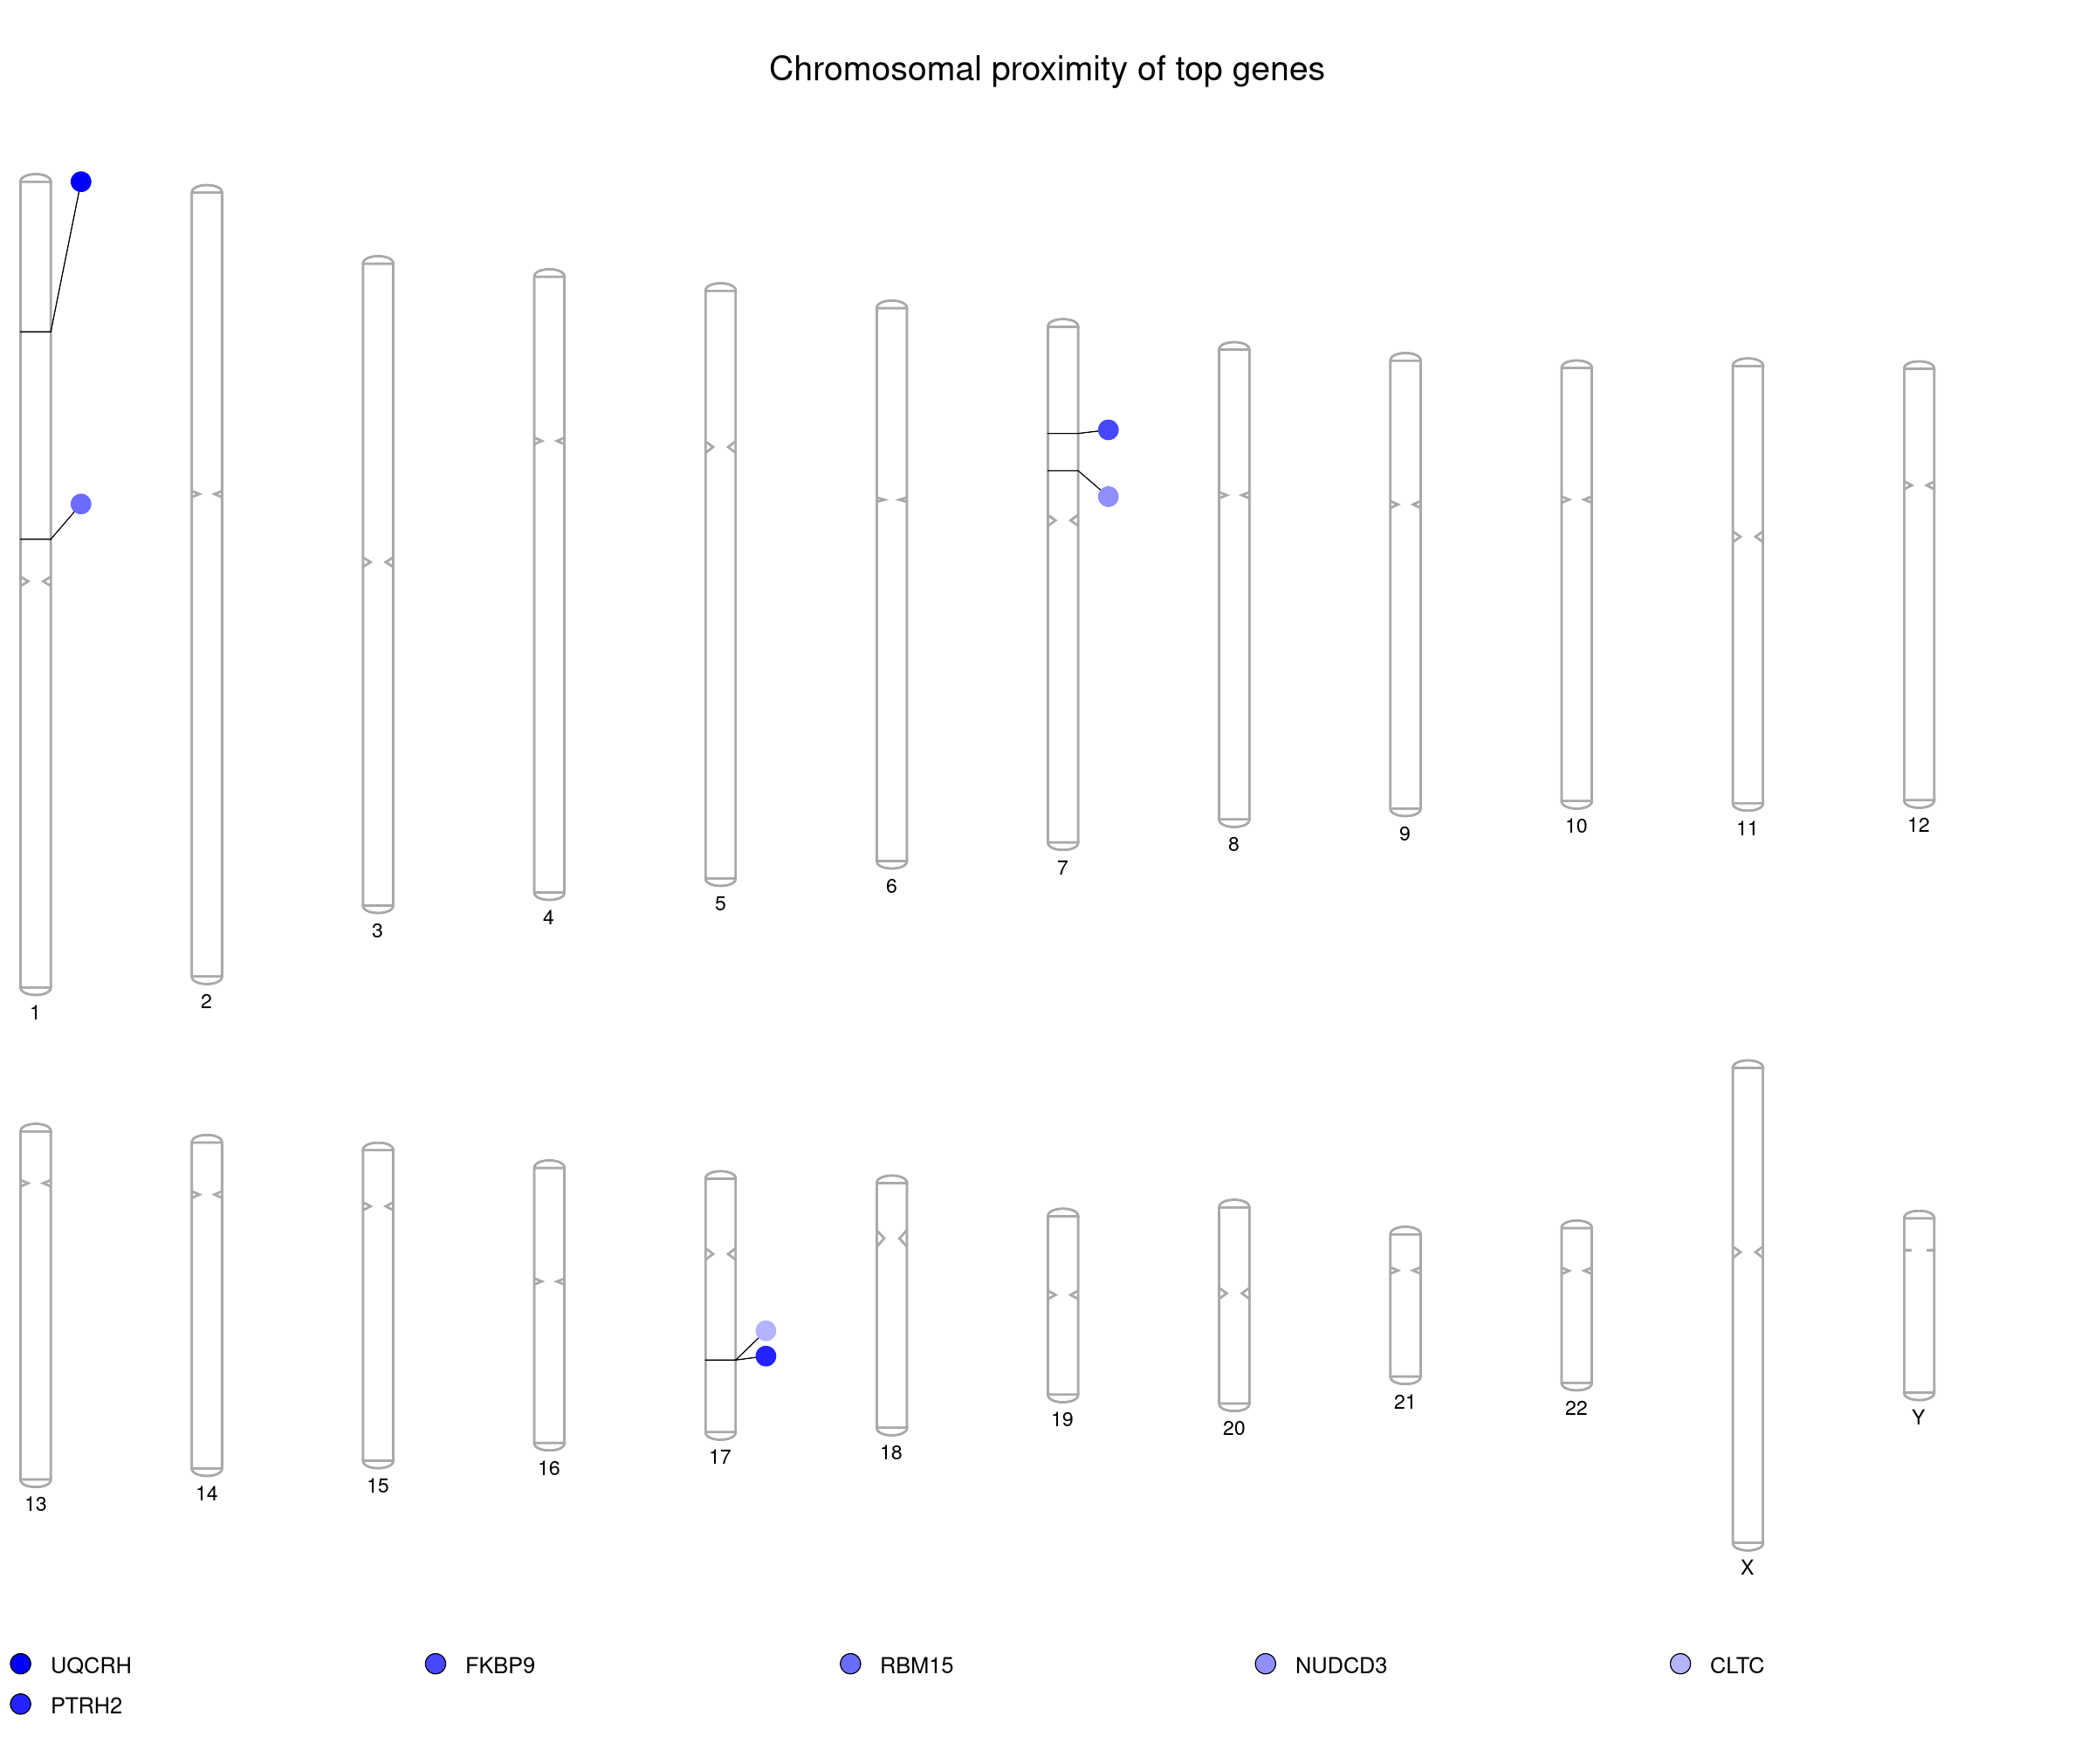

In [95]:
display(Image(filename="pheno_gram.20576.png"))